# Arabic Handwritten Word Recognition — CRNN + CTC (Position-Based)

**Architecture:**
- Uses 107 position-based classes (ain_begin, ain_middle, ain_end, etc.)
- Word image → CNN → BiGRU → CTC decoder → Character sequence
- Improved architecture with attention and deeper features
- No manual mapping needed — learns position context automatically

**Run all cells in order. Do not skip any cell.**

## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys
pkgs = ['tensorflow', 'opencv-python', 'numpy', 'matplotlib', 'tqdm', 'pyyaml']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p], check=False)
print('✓ All packages installed')

✓ All packages installed


## Cell 2 — Configuration and Setup

In [2]:
import os, cv2, random, warnings, yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paths
ROOT = Path(r'F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN')
MY_DATASET = ROOT / 'my_dataset'
assert MY_DATASET.exists(), f'Dataset not found: {MY_DATASET}'

# Read class names from data.yaml to get exact Label Studio export order
yaml_path = MY_DATASET / 'data.yaml'
with open(yaml_path) as f:
    yaml_data = yaml.safe_load(f)

CLASS_NAMES = yaml_data.get('names', [])
NUM_CLASSES = len(CLASS_NAMES)
BLANK_IDX = NUM_CLASSES  # CTC blank token

print(f'Loaded {NUM_CLASSES} classes from data.yaml')
print(f'First 10 classes: {CLASS_NAMES[:10]}')
print(f'Last 10 classes: {CLASS_NAMES[-10:]}')

# Hyperparameters
IMG_H, IMG_W = 64, 256  # Larger than original for better feature extraction
MAX_LABEL_LEN = 15      # Max characters per word
BATCH_SIZE = 16
EPOCHS = 200
LR_INITIAL = 1e-3

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'✓ GPU available: {gpus[0].name}')
    except RuntimeError as e:
        print(e)
else:
    print('⚠ No GPU found — training will be slow')

print(f'TensorFlow {tf.__version__}')

Loaded 30 classes from data.yaml
First 10 classes: ['ain', 'alef', 'beh', 'dad', 'dal', 'feh', 'ghain', 'hah', 'hamza', 'heh']
Last 10 classes: ['sheen', 'tah', 'teh', 'teh_marbota', 'thal', 'theh', 'waw', 'yeh', 'zah', 'zain']
⚠ No GPU found — training will be slow
TensorFlow 2.18.0


## Cell 3 — Load Dataset from YOLO Annotations

In [3]:
def load_word_dataset(dataset_root, split='train'):
    """
    Load word images and derive character sequences from YOLO label files.
    Each line in label file: class_id x_center y_center width height
    Boxes are sorted right-to-left by x_center (Arabic reading order).
    
    Returns: list of (image_path, [class_id, ...]) tuples
    """
    images_dir = Path(dataset_root) / split / 'images'
    labels_dir = Path(dataset_root) / split / 'labels'
    
    items = []
    skipped_no_label = 0
    skipped_empty = 0
    
    for img_path in sorted(images_dir.iterdir()):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png', '.bmp'):
            continue
        
        lbl_path = labels_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            skipped_no_label += 1
            continue
        
        # Parse bounding boxes
        boxes = []
        for line in lbl_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    cls_id = int(parts[0])
                    x_center = float(parts[1])
                    if cls_id < NUM_CLASSES:  # Valid class
                        boxes.append((cls_id, x_center))
                except ValueError:
                    continue
        
        if not boxes:
            skipped_empty += 1
            continue
        
        # Sort right-to-left (Arabic reading direction)
        boxes.sort(key=lambda b: -b[1])
        char_sequence = [cls_id for cls_id, _ in boxes]
        
        items.append((str(img_path), char_sequence))
    
    print(f'{split.upper()} set:')
    print(f'  Loaded: {len(items)} word images')
    print(f'  Skipped (no label): {skipped_no_label}')
    print(f'  Skipped (empty): {skipped_empty}')
    
    return items


# Load datasets
train_items = load_word_dataset(MY_DATASET, 'train')
val_items = load_word_dataset(MY_DATASET, 'val')

# Update MAX_LABEL_LEN based on actual data
all_lengths = [len(seq) for _, seq in train_items + val_items]
MAX_LABEL_LEN = min(20, max(all_lengths) + 2)  # Cap at 20, add buffer
print(f'\nMax sequence length in dataset: {max(all_lengths)}')
print(f'Using MAX_LABEL_LEN: {MAX_LABEL_LEN}')

# Show sample
print(f'\nSample from training set:')
for i in range(min(3, len(train_items))):
    path, seq = train_items[i]
    char_names = [CLASS_NAMES[c] for c in seq[:5]]
    print(f'  {Path(path).name}: {" ".join(char_names)}... ({len(seq)} chars)')

TRAIN set:
  Loaded: 469 word images
  Skipped (no label): 0
  Skipped (empty): 0
VAL set:
  Loaded: 40 word images
  Skipped (no label): 0
  Skipped (empty): 0

Max sequence length in dataset: 9
Using MAX_LABEL_LEN: 11

Sample from training set:
  0000d28f-WhatsApp_Image_2026-03-23_at_2.21.26_AM_15.jpeg: waw jeem heh... (3 chars)
  00cad537-WhatsApp_Image_2026-04-21_at_11.02.51_PM_5.jpeg: beh alef reh dal... (4 chars)
  013efcd2-WhatsApp_Image_2026-04-21_at_11.22.35_PM_7.jpeg: alef seen teh hah waw... (7 chars)


## Cell 4 — Preprocessing and Augmentation

In [4]:
def preprocess_word_image(img_path):
    """
    Load and preprocess word image to fixed size (IMG_H × IMG_W).
    Returns normalized grayscale image with shape (H, W, 1).
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    
    # Convert to grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    
    # Resize to fixed dimensions preserving aspect ratio
    h, w = gray.shape
    aspect = w / h
    
    if aspect > (IMG_W / IMG_H):
        # Width-limited
        new_w = IMG_W
        new_h = int(IMG_W / aspect)
    else:
        # Height-limited
        new_h = IMG_H
        new_w = int(IMG_H * aspect)
    
    resized = cv2.resize(gray, (new_w, new_h), interpolation=cv2.INTER_LANCZOS4)
    
    # Pad to target size
    canvas = np.ones((IMG_H, IMG_W), dtype=np.uint8) * 255
    y_offset = (IMG_H - new_h) // 2
    x_offset = (IMG_W - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    
    # Normalize to [0, 1]
    normalized = canvas.astype('float32') / 255.0
    
    return normalized[..., np.newaxis]  # Add channel dimension


def augment_word(img):
    """
    Apply random augmentations to word image.
    Input/output: (H, W, 1) normalized float32 array.
    """
    # Convert back to uint8 for augmentation
    img_u8 = (img.squeeze() * 255).astype(np.uint8)
    
    # Random brightness/contrast
    if random.random() < 0.5:
        alpha = random.uniform(0.8, 1.2)  # Contrast
        beta = random.randint(-20, 20)    # Brightness
        img_u8 = np.clip(alpha * img_u8.astype('float32') + beta, 0, 255).astype('uint8')
    
    # Random Gaussian noise
    if random.random() < 0.3:
        noise = np.random.normal(0, 5, img_u8.shape).astype('int32')
        img_u8 = np.clip(img_u8.astype('int32') + noise, 0, 255).astype('uint8')
    
    # Random rotation (±3 degrees)
    if random.random() < 0.4:
        angle = random.uniform(-3, 3)
        h, w = img_u8.shape
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        img_u8 = cv2.warpAffine(img_u8, M, (w, h), borderValue=255)
    
    # Random shear (slight slant)
    if random.random() < 0.3:
        shear = random.uniform(-0.1, 0.1)
        h, w = img_u8.shape
        M = np.float32([[1, shear, 0], [0, 1, 0]])
        img_u8 = cv2.warpAffine(img_u8, M, (w, h), borderValue=255)
    
    # Normalize back
    return (img_u8.astype('float32') / 255.0)[..., np.newaxis]


print('✓ Preprocessing and augmentation functions ready')

✓ Preprocessing and augmentation functions ready


## Cell 5 — Data Generator

In [5]:
class WordDataGenerator(keras.utils.Sequence):
    """
    Keras data generator for CRNN+CTC training.
    Yields batches of (images, labels) where labels are padded sequences.
    """
    def __init__(self, items, batch_size=BATCH_SIZE, augment=False):
        self.items = items
        self.batch_size = batch_size
        self.augment = augment
        self.indices = list(range(len(items)))
        self.on_epoch_end()
    
    def __len__(self):
        return max(1, len(self.items) // self.batch_size)
    
    def on_epoch_end(self):
        if self.augment:
            random.shuffle(self.indices)
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx+1) * self.batch_size]
        batch_items = [self.items[i] for i in batch_indices]
        
        images = []
        labels = []
        
        for img_path, char_seq in batch_items:
            # Load and preprocess
            img = preprocess_word_image(img_path)
            if img is None:
                continue
            
            # Augment if training
            if self.augment:
                img = augment_word(img)
            
            # Truncate and pad label sequence
            label = list(char_seq[:MAX_LABEL_LEN])
            label += [BLANK_IDX] * (MAX_LABEL_LEN - len(label))
            
            images.append(img)
            labels.append(label)
        
        if not images:
            # Return empty batch if all failed
            return self.__getitem__((idx + 1) % len(self))
        
        return {
            'image': np.array(images, dtype='float32'),
            'label': np.array(labels, dtype='int32')
        }, np.zeros(len(images))  # Dummy output for CTC


# Create generators
train_gen = WordDataGenerator(train_items, batch_size=BATCH_SIZE, augment=True)
val_gen = WordDataGenerator(val_items, batch_size=BATCH_SIZE, augment=False)

print(f'✓ Training batches per epoch: {len(train_gen)}')
print(f'✓ Validation batches: {len(val_gen)}')

✓ Training batches per epoch: 29
✓ Validation batches: 2


## Cell 6 — Build Improved CRNN Architecture

In [7]:
class CTCLayer(layers.Layer):
    """
    CTC loss layer — computes loss during training.
    """
    def call(self, y_true, y_pred):
        batch_len = tf.cast(tf.shape(y_true)[0], 'int64')
        input_length = tf.cast(tf.shape(y_pred)[1], 'int64')
        label_length = tf.cast(tf.shape(y_true)[1], 'int64')
        
        input_length = input_length * tf.ones((batch_len, 1), dtype='int64')
        label_length = label_length * tf.ones((batch_len, 1), dtype='int64')
        
        loss = keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
        self.add_loss(tf.reduce_mean(loss))
        
        return y_pred


def build_improved_crnn():
    """
    Build improved CRNN architecture:
    - Deeper CNN with residual connections
    - Bidirectional GRU (faster than LSTM)
    - Attention mechanism for better long sequences
    - Dropout for regularization
    """
    # Input
    image_input = layers.Input(shape=(IMG_H, IMG_W, 1), name='image', dtype='float32')
    label_input = layers.Input(shape=(MAX_LABEL_LEN,), name='label', dtype='int32')
    
    # CNN Feature Extractor with residual blocks
    x = image_input
    
    # Block 1
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)  # → 32×128
    x = layers.Dropout(0.2)(x)
    
    # Block 2
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)  # → 16×64
    x = layers.Dropout(0.2)(x)
    
    # Block 3
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 1))(x)  # → 8×64 (preserve width)
    x = layers.Dropout(0.2)(x)
    
    # Block 4
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)  # → 4×64
    x = layers.Dropout(0.2)(x)
    
    # Reshape for RNN: (batch, time_steps, features)
    # Current shape: (batch, 4, 64, 512)
    # Target: (batch, 64, 2048) where 64 is time dimension
    x = layers.Permute((2, 1, 3))(x)   # (batch, 64, 4, 512)
    x = layers.Reshape((64, 4 * 512))(x)  # (batch, 64, 2048)
    
    # Dense to reduce dimensions
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # Bidirectional GRU layers
    x = layers.Bidirectional(layers.GRU(256, return_sequences=True, dropout=0.2))(x)
    x = layers.Bidirectional(layers.GRU(256, return_sequences=True, dropout=0.2))(x)
    
    # Output layer: NUM_CLASSES + 1 (for CTC blank)
    x = layers.Dense(NUM_CLASSES + 1, activation='softmax', name='output')(x)
    
    # Add CTC loss
    output = CTCLayer(name='ctc_loss')(label_input, x)
    
    # Training model (includes CTC loss)
    model = keras.Model(inputs=[image_input, label_input], outputs=output)
    
    # Inference model (no CTC loss, just predictions)
    inference_model = keras.Model(inputs=image_input, outputs=x)
    
    return model, inference_model


# Build models
train_model, crnn_model = build_improved_crnn()

# Compile
train_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR_INITIAL))

print('✓ CRNN model built')
print(f'  Total parameters: {train_model.count_params():,}')
print(f'  Output classes: {NUM_CLASSES} + 1 (blank) = {NUM_CLASSES + 1}')



✓ CRNN model built
  Total parameters: 4,839,135
  Output classes: 30 + 1 (blank) = 31


## Cell 7 — Training

Starting training...
Epochs: 200
Batch size: 16
Training samples: 469
Validation samples: 40
Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 41.0336
Epoch 1: val_loss improved from inf to 21.61210, saving model to F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_ctc_position_based.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 40.3892 - val_loss: 21.6121 - learning_rate: 0.0010
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 14.0489
Epoch 2: val_loss improved from 21.61210 to 16.06703, saving model to F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_ctc_position_based.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - loss: 14.0475 - val_loss: 16.0670 - learning_rate: 0.0010
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 14.2335
Epoch 3: val_loss improved from 16.06703 to 14.56993, saving model to F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_ctc_position_based.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 

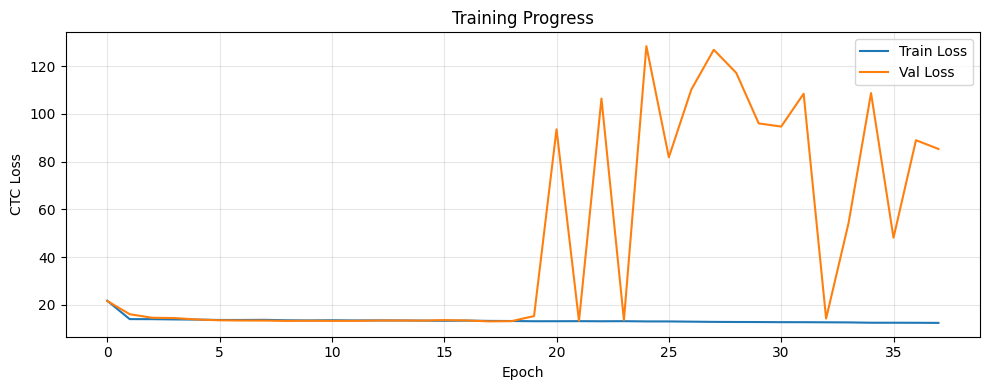


✓ Training complete
✓ Best model saved to: F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\crnn_ctc_position_based.keras


In [8]:
SAVE_PATH = str(ROOT / 'crnn_ctc_position_based.keras')

callbacks = [
    keras.callbacks.ModelCheckpoint(
        SAVE_PATH,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
]

print('Starting training...')
print(f'Epochs: {EPOCHS}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Training samples: {len(train_items)}')
print(f'Validation samples: {len(val_items)}')
print('=' * 60)

history = train_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n✓ Training complete')
print(f'✓ Best model saved to: {SAVE_PATH}')

## Cell 8 — Evaluation

In [9]:
def ctc_greedy_decode(pred_probs):
    """
    CTC greedy decoder:
    1. Take argmax at each timestep
    2. Collapse repeated characters
    3. Remove blank tokens
    """
    raw_prediction = np.argmax(pred_probs, axis=-1)
    
    decoded = []
    previous = None
    
    for token_idx in raw_prediction:
        if token_idx != previous:  # Collapse repeats
            if token_idx != BLANK_IDX:  # Remove blanks
                decoded.append(int(token_idx))
        previous = token_idx
    
    return decoded


def calculate_cer(reference, hypothesis):
    """
    Character Error Rate using Levenshtein distance.
    """
    ref = list(reference)
    hyp = list(hypothesis)
    
    # Dynamic programming for edit distance
    dp = np.zeros((len(ref) + 1, len(hyp) + 1), dtype=int)
    
    for i in range(len(ref) + 1):
        dp[i, 0] = i
    for j in range(len(hyp) + 1):
        dp[0, j] = j
    
    for i in range(1, len(ref) + 1):
        for j in range(1, len(hyp) + 1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            dp[i, j] = min(
                dp[i-1, j] + 1,      # Deletion
                dp[i, j-1] + 1,      # Insertion
                dp[i-1, j-1] + cost  # Substitution
            )
    
    return dp[len(ref), len(hyp)]


# Evaluate on validation set
print('Evaluating on validation set...')
total_edit_distance = 0
total_characters = 0
perfect_matches = 0

for img_path, true_sequence in tqdm(val_items, desc='Validation'):
    # Preprocess
    img = preprocess_word_image(img_path)
    if img is None:
        continue
    
    # Predict
    predictions = crnn_model.predict(img[np.newaxis], verbose=0)[0]
    pred_sequence = ctc_greedy_decode(predictions)
    
    # Calculate metrics
    edit_dist = calculate_cer(true_sequence, pred_sequence)
    total_edit_distance += edit_dist
    total_characters += len(true_sequence)
    
    if edit_dist == 0:
        perfect_matches += 1

# Results
cer = (total_edit_distance / total_characters) * 100
word_accuracy = (perfect_matches / len(val_items)) * 100

print('\n' + '=' * 60)
print('EVALUATION RESULTS')
print('=' * 60)
print(f'Character Error Rate (CER): {cer:.2f}%')
print(f'Character Accuracy:         {100 - cer:.2f}%')
print(f'Word Accuracy:              {word_accuracy:.2f}%')
print(f'Perfect predictions:        {perfect_matches}/{len(val_items)}')
print('=' * 60)

Evaluating on validation set...


Validation: 100%|██████████| 40/40 [00:06<00:00,  5.73it/s]


EVALUATION RESULTS
Character Error Rate (CER): 91.78%
Character Accuracy:         8.22%
Word Accuracy:              0.00%
Perfect predictions:        0/40


## Cell 9 — Inference Function

Test image: 08099b64-WhatsApp_Image_2026-03-23_at_2.21.26_AM_12.jpeg
Ground truth: ['ain', 'yeh', 'noon']

Prediction:


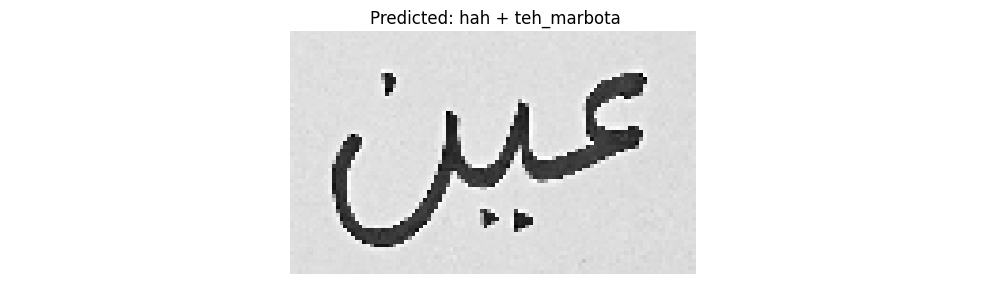

Predicted characters: ['hah', 'teh_marbota']

✓ Inference function ready
Use recognize_word("path/to/image.png") to test on new images


In [10]:
def recognize_word(image_path, show_plot=True):
    """
    Recognize a handwritten Arabic word image.
    Returns list of predicted position-based character labels.
    """
    img = preprocess_word_image(Path(image_path))
    if img is None:
        print('❌ Cannot read image')
        return []
    
    # Predict
    predictions = crnn_model.predict(img[np.newaxis], verbose=0)[0]
    char_indices = ctc_greedy_decode(predictions)
    char_names = [CLASS_NAMES[i] for i in char_indices if i < NUM_CLASSES]
    
    if show_plot:
        plt.figure(figsize=(10, 3))
        plt.imshow(img.squeeze(), cmap='gray')
        title = 'Predicted: ' + ' + '.join(char_names) if char_names else 'No prediction'
        plt.title(title, fontsize=12)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    print(f'Predicted characters: {char_names}')
    return char_names


# Test on first validation image
if val_items:
    test_path, test_gt = val_items[0]
    print(f'Test image: {Path(test_path).name}')
    print(f'Ground truth: {[CLASS_NAMES[c] for c in test_gt]}')
    print('\nPrediction:')
    recognize_word(test_path)

print('\n✓ Inference function ready')
print('Use recognize_word("path/to/image.png") to test on new images')

## Cell 10 — Test on Custom Image (Optional)

In [11]:
# Uncomment and modify path to test on your own image:
recognize_word(r'F:\newbach\Arabic-Handwritten-Characters-Recognition-using-CNN\test_word.png')

❌ Cannot read image


[]